# Computational Social Science Project #3 

**Enter your Name:** Karla Palos Castellanos

*Semester:* Fall 2023

## 1. Introduction

### Load data 

In [1]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [3]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [4]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [5]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [6]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

In [7]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 

<Axes: title={'center': 'Inspections by Month and Year'}, xlabel='Inspection_MonthYear'>

Let's visualize what the distribution of results looks like.

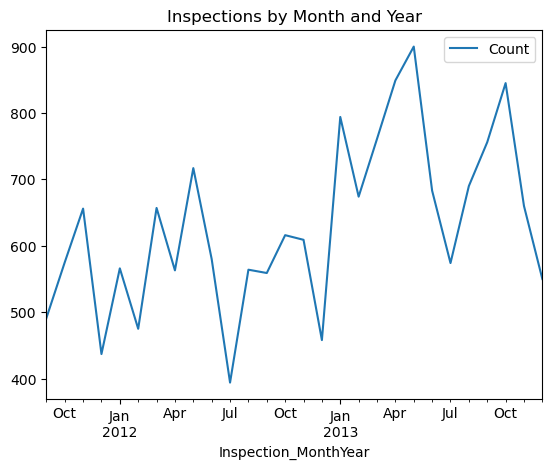

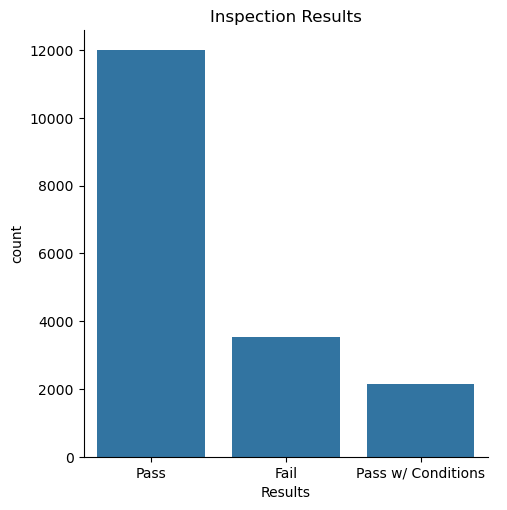

In [8]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

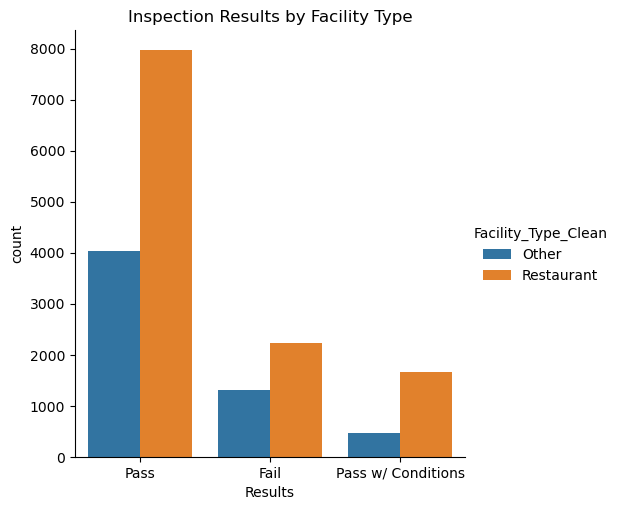

In [9]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [10]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [11]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])
# inspect X 
X.head()



,,Risk,Inspection_Type,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,APPLICATION_TYPE,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,Risk 3 (Low),Canvass,Other,0,0,2,0,0,0,0,2.0,1,19.0,RENEW,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
507211,PANERA BREAD,Risk 1 (High),Canvass,Restaurant,0,0,3,0,0,0,0,2.0,1,24.0,RENEW,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
507212,LITTLE QUIAPO RESTAURANT,Risk 1 (High),Canvass,Restaurant,0,2,6,0,0,0,0,2.0,1,17.0,RENEW,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
507216,SERGIO'S TAQUERIA PIZZA INC.,Risk 1 (High),Canvass,Restaurant,0,0,6,0,0,0,0,2.0,1,17.0,RENEW,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
507219,TARGET STORE # T-2079,Risk 2 (Medium),Canvass,Restaurant,0,2,6,0,0,0,0,2.0,1,24.0,RENEW,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0


In [12]:
# get dummies
X = pd.get_dummies(X)

# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

In [13]:
# Split Data 
from sklearn.model_selection import train_test_split

# Set seed
np.random.seed(10)


# Train and validation stplit 
    # The 20% split we are creating is the validation set. The real test set is the 2014 inpection data.

y_flat = y.ravel() # Convert it to a 1D array of length n (We do this since sckit-learn expects the target to be 1 dimensional) 

X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y_flat, 
                                                  train_size = .80, 
                                                  test_size=0.20,   
                                                  stratify=y_flat,
                                                  random_state=42)


# We will use x_train and y_train for fitting+ cross validation, and the x_val,y_val for the final comparison 
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)


(12248, 41) (3063, 41)
(12248,) (3063,)


In [14]:
# Import libraries to run our models 

from sklearn.ensemble import AdaBoostClassifier #boosting model 
from sklearn.preprocessing import StandardScaler # used to standarize numerical variables. 


from sklearn.model_selection import GridSearchCV # For cross-validation. Helps us find the best hyperparamter of the model 

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import cross_val_score

### Model 1 : Logistic Regression 

Why is is appropiate 
- Logistic regression is appropriate because it gives clear and interpretable probabilities of a restaurant failing an inspection.

PROS: 
- easy to interpret
- runs quickly

CONS: 
- can miss non linear patters
- Assumes leaner relationship betweent the features and the failure

How I will train it 
- use cross validation and grid of paramters to find the version with the best F1 score and then evaluate it on the validation data set 

In [15]:
# Import libraries 
from sklearn.linear_model import LogisticRegression # linear classifier --> log odds

# Create a model
log_reg = LogisticRegression()
 
# Fit the model 
log_model = log_reg.fit(X_train, y_train) # This is the furst log reg fitted with default settings 
    # here we are training our model on the training data 
    # X - train = the features for the training cases , which are the restaurants
    # y - the lables for those cases (0 = pass, 1 = fail) 
    # After this, the log model learns the coefficients that it thinks best separate pass vs fail based on the training data 

# Predict on the validation data 
y_pred = log_model.predict(X_val)
    # Now we use the trained model to predict outcomes for the validation data set 
    # X test are restaurants the model hasn't seen during training  (validation split)
    # y_pred is just the list/array of 0 and 1s the model's guess for pass/fail 



In [16]:
# Hyperparameter tuning--> Let's apply the grid search to a logistic regresssion model to find the best hyperparameter values


# Set parameters 
log_param_grid = {'penalty': ['l1', 'l2'],       # --> tells model how to regularize 
        'C': np.arange(.1, 1, .1),           # --> controls how strong the regularization is  
        'fit_intercept': [True, False],      
         'solver': ['liblinear','saga']}     #--> which optiomization algorithm to use 

# execute the grid search and fit to training data
log_grid_reg = GridSearchCV(log_model, 
                            log_param_grid, 
                            cv=3, 
                            scoring='f1')   
                                                     # Run a cross validation (cv=3) for every combination in the params var above. 
                                                     # The goal is to test different versions of logistic regression with these 
                                                     # parameter combinations and pick the best one 
log_grid_reg.fit(X_train, 
                 y_train)                   # Runs the full hyperparam seach --> trains the model on different folds, evals each one, and stores the resul in cv_results, and chooses the bets model 

# choose best performing mode
best_index = np.argmax(log_grid_reg.cv_results_["mean_test_score"])  # find the best index of the best performing param co 
print(log_grid_reg.cv_results_["params"][best_index])

# Use the best model to prdict on validation data
best_log_pred = log_grid_reg.best_estimator_.predict(X_val) # after we rang GridsearchSV, this is our best model --> log_grid_reg.best_estimator_.
    # Now, we use the best model to make predictions on the validation data 
    # Our model was trained on X_train, and has not seen the X_val before, so this predeiction will tell use how well the model generalizes

{'C': np.float64(0.1), 'fit_intercept': True, 'penalty': 'l1', 'solver': 'liblinear'}


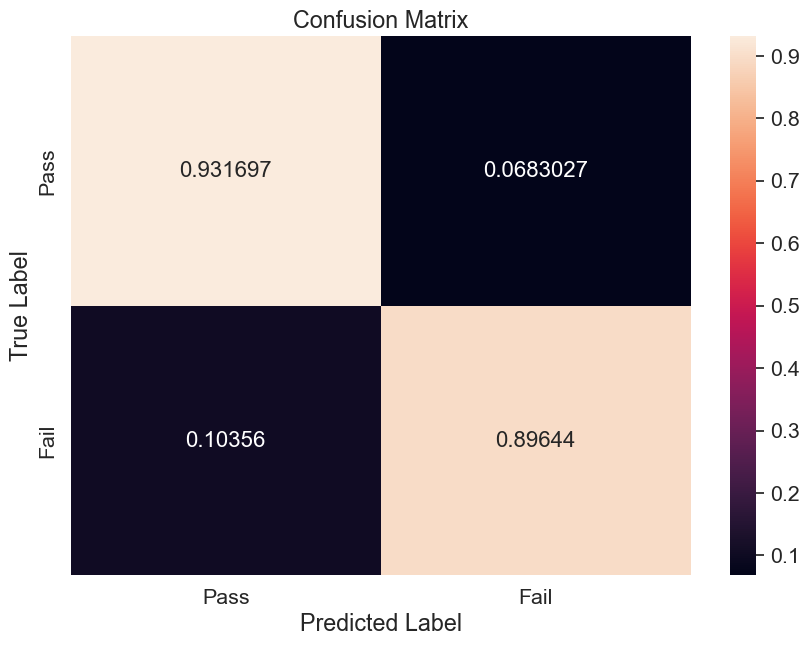

Validation Precision: 0.768377253814147
Validation Accuracy 0.9245837414299706
Validation Recall   : 0.8964401294498382
Validation F1       : 0.8274831964152353


In [17]:
# Metrics 

# specify confusion matrix
cf_matrix = confusion_matrix(y_val, 
                             best_log_pred, 
                             normalize = "true")

# convert to dataframe
df_cm = pd.DataFrame(cf_matrix, 
                     range(2),
                     range(2))

# label dataframe 
df_cm = df_cm.rename(index=str, columns={0: "Pass", 1: "Fail"})
df_cm.index = ["Pass", "Fail"]

# plot
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(df_cm, 
           annot=True,
           annot_kws={"size": 16},
           fmt='g')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

    # We want to compute the accuracy by comparing the true labels in y_lab, and the models predictions, 
    # and so the accuracy is the % of predictios the model got right. 
    # ---> so how many restaurants did the model correctly classify on the validation set
print("Validation Precision:", precision_score(y_val, best_log_pred))
print('Validation Accuracy', accuracy_score(y_val,best_log_pred)) 
print("Validation Recall   :", recall_score(y_val, best_log_pred))
print("Validation F1       :", f1_score(y_val, best_log_pred))

## Model 2 - Random Forest

Why is is appropiate 
- RF is appropriate because restaurant inspections involve complex patterns (e.g. interactions between past violations, restaurant type, location, and time since last visit), and it can automatically capture non-linear relationships and interactions without us needing to specify them.

  
PROS: 
- Can easily deal with non-linear and interaction effects
- More accurate than simple models
- Less likely to overfit than a single tree

CONS: 
- Harder to intepret 

How I will train it 
- I tuned tree depth, number of trees, and split rules using GridSearchCV, then used the best model on the validation set.

In [18]:
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier 


In [19]:
# create model 
dt_classifier = tree.DecisionTreeClassifier(random_state = 5) #random seed
    
# set hyperparamter grid to search over 
dt_param_grid = {
    'criterion': ['gini', 'entropy'],   # for information gain 
    'max_depth': [None, 5, 10, 20],     # how deep the tree can grow
    'min_samples_split': [2, 10, 20],   # min samples needed to split a node
    'min_samples_leaf': [1, 5, 10],     # min samples in a leaf
    'max_features': [None, 'sqrt', 'log2'] # how many features to consider at each split
}

# execute the grid search 
dt_grid = GridSearchCV(
    estimator=dt_classifier ,
    param_grid=dt_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# fit to data 
    # at this point, scikit-learn has trained many decison trees, evaluated each using corss-validated, and stored the best-performing model 
dt_grid.fit(X_train, y_train)

# get the bnest model 
best_dt = dt_grid.best_estimator_
print("Best decision tree params: ", dt_grid.best_params_)

# make predictions oon the vlaidation set 
y_pred_dt = best_dt.predict(X_val)


Best decision tree params:  {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}


In [20]:

# Evaluate! 
print("Validation Accuracy :",  accuracy_score(y_val, y_pred_dt))
print("Validation Precision:", precision_score(y_val, y_pred_dt))
print("Validation Recall   :", recall_score(y_val, y_pred_dt))
print("Validation F1       :", f1_score(y_val, y_pred_dt))    

Validation Accuracy : 0.921645445641528
Validation Precision: 0.7554054054054054
Validation Recall   : 0.9045307443365695
Validation F1       : 0.8232695139911634


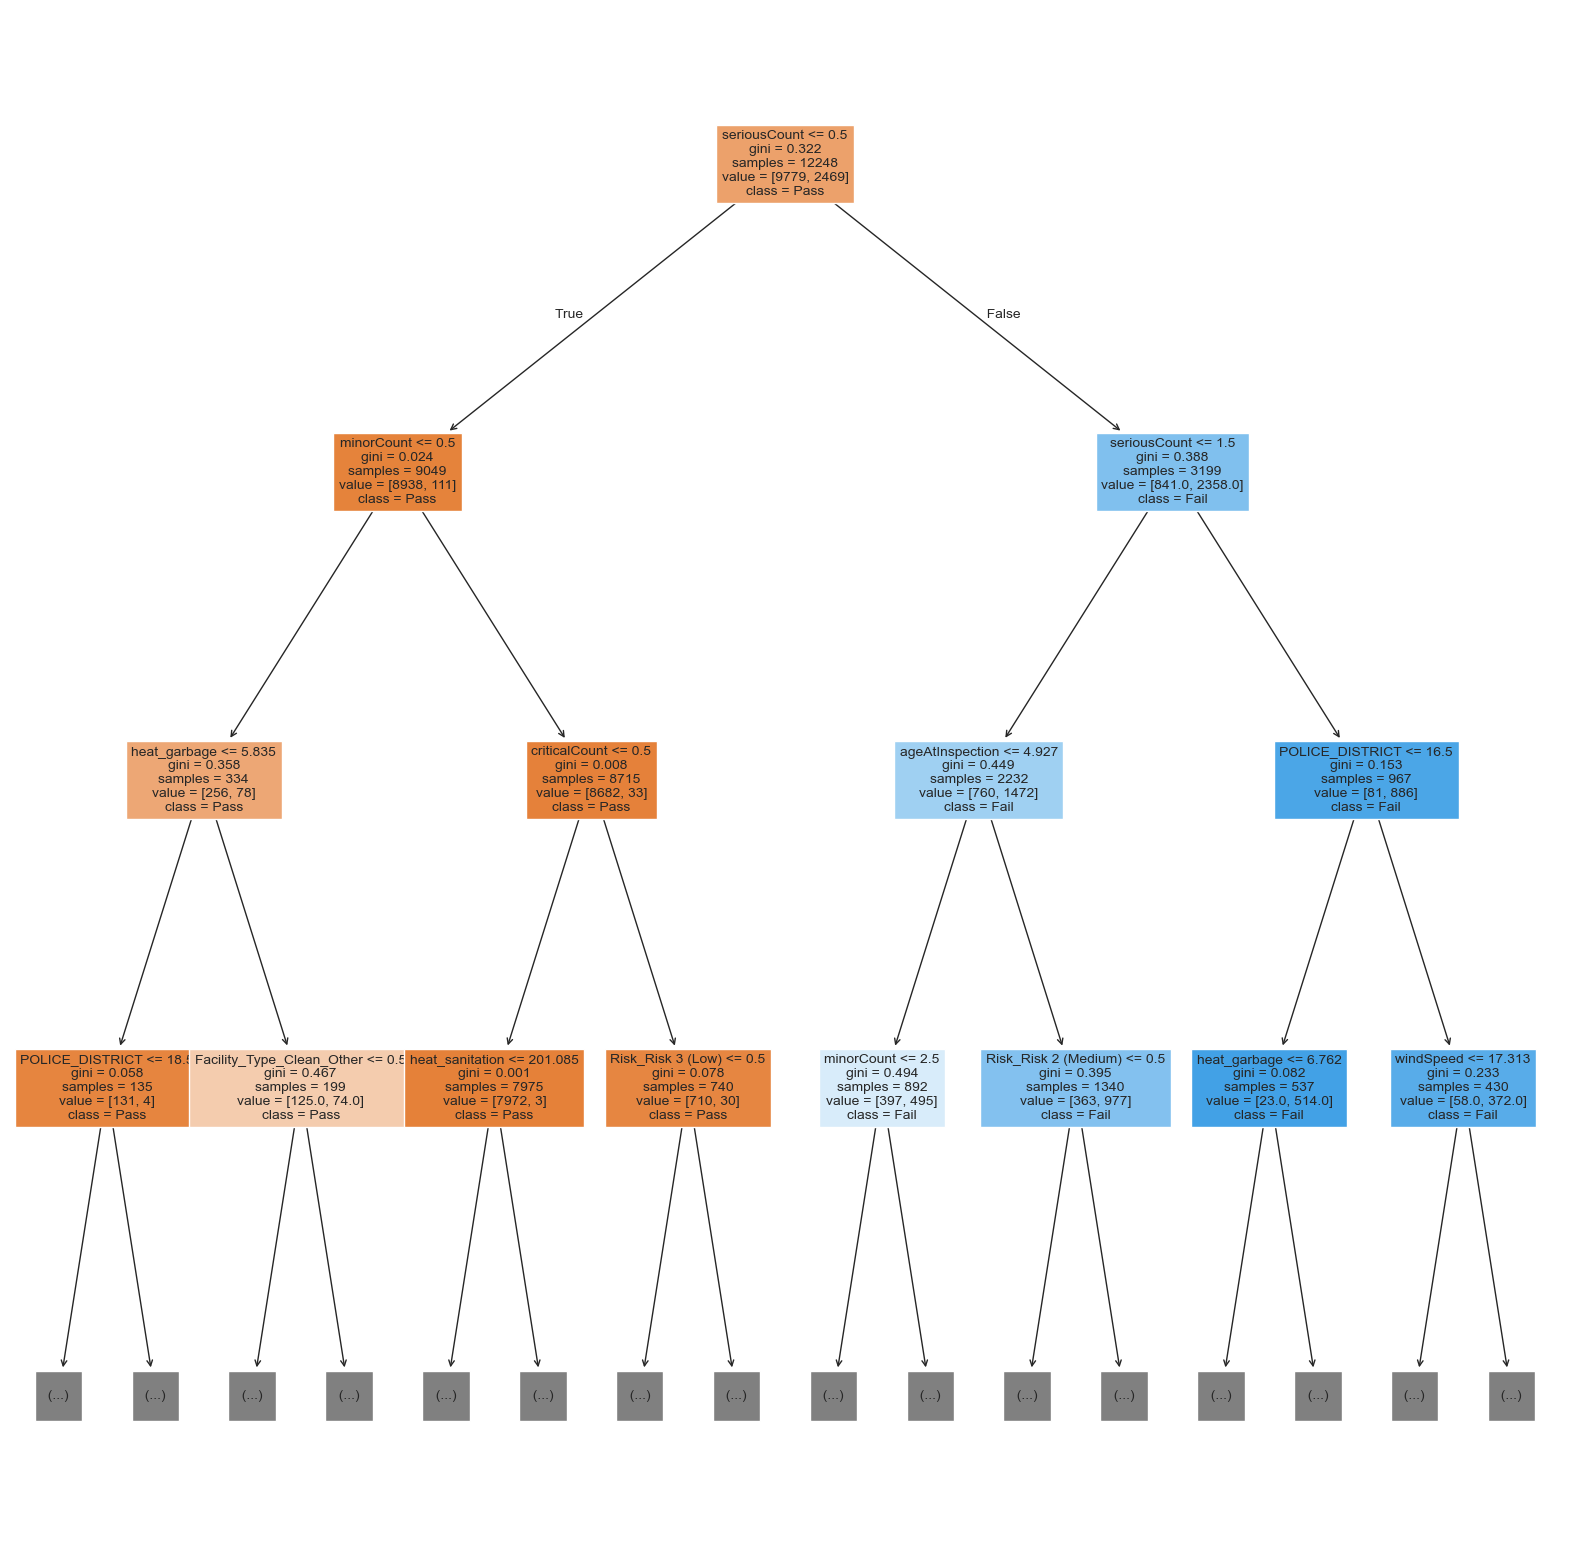

In [21]:
fig, ax = plt.subplots(figsize=(20,20))
tree.plot_tree(
    best_dt,
    feature_names=X_train.columns.tolist(),
    class_names=["Pass", "Fail"],
    filled=True,
    fontsize=10,
    max_depth=3
)

plt.show()

###  Model 3: XGBOOST

Why is is appropiate 
- This model is appropriate because it performs extremely well on data like the one on this project.
- It can easily pick up patterns in the data
- Strong model when the goal is accurate prioritization, which fits the goals of the project 
  
PROS: 
- strong predictive performance
- can capture complex patterns really well
- built in mechanism to avoid overfitting

CONS: 
- Harder to intepret
- Tunning requires more work 

How I will train it 
- I tuned depth, number of rounds, learning rate, and subsampling using GridSearchCV, then validated the best-performing model.

In [22]:
#!pip install xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [23]:
# Base XGBoost model
xgb = XGBClassifier(
    objective='binary:logistic',  # we have a 0/1 outcome
    eval_metric='logloss',        # needed to silence warnings
    random_state=42,
    n_estimators=200,             # will be tuned, but good default
    use_label_encoder=False
)

# Hyperparameter grid 
xgb_param_grid = {
    'n_estimators': [100, 200],        # number of trees
    'max_depth': [3, 5, 7],            # depth of each tree
    'learning_rate': [0.05, 0.1],      # shrinkage
    'subsample': [0.8, 1.0],           # row subsampling
    'colsample_bytree': [0.8, 1.0]     # feature subsampling per tree
}

# Grid search with 3-fold CV, optimizing F1 
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit on training data
xgb_grid.fit(X_train, y_train)

# Best XGBoost model
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost params:", xgb_grid.best_params_)

# Predict on validation data
y_pred_xgb = best_xgb.predict(X_val)

# Evaluate! 
print("\nXGBoost Validation Metrics:")
print("Accuracy :",  accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall   :", recall_score(y_val, y_pred_xgb))
print("F1 Score :", f1_score(y_val, y_pred_xgb))

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:18:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

XGBoost Validation Metrics:
Accuracy : 0.9285014691478942
Precision: 0.7699594046008119
Recall   : 0.9207119741100324
F1 Score : 0.8386145910095799


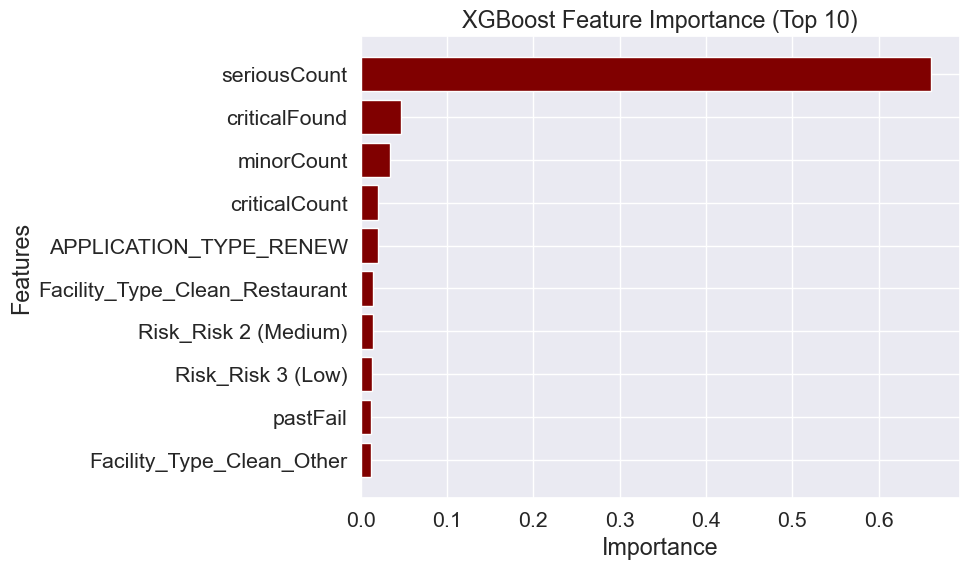

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from tuned XGBoost model
xgb_importances = best_xgb.feature_importances_   

# Put into a df with column names
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_importances
})

# Sort by importance and keep top 10
feat_imp = feat_imp.sort_values('importance', ascending=False)
top10 = feat_imp.head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'], color='maroon', align='center')
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance (Top 10)')
plt.tight_layout()
plt.show()

### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

For each model I reported (See outoput under each model)
- Accuracy: % correctly predicted
- Precision: Of those predicted fail, how many actually failed
- Recall: Of the restaurants that did fail, how many the model caught
- F1 Score: Balance of precision + recall

For this project, the metrics that matter the most are recall and F1 scores. The reason is that a false negative (i.e. the model saying that is passes but the place actually would fail inspection), would be worst mistake since it would mean that a potentially unsafe restaurant was not inspected sooner and increases the risk of public health related consequences like contamination and diseases. The whole goal of our predictive model is to be able to prioritze what restaurants nee the mostt attention, this means that it should be good at catching failures, which is what the recall measures. --> a model wil low recall would let the unsafe restaurants get a pass. Additionally, we also need to balabce false postives, eventhough on this case they are less harmful. In our case, the model would say fail, when the restaurant actually would pass. This means that in the worst scenario, you would have somone who spent time inpecting it when the time could had been used elsewhere, but it would not pose a public health risk. And so, the F1 helps us balance  precision and recall. In other words, it balances catching the at-risk retaurants and at the same time aboids too many uncessary inspections. 

Thus our best model would be one that has a high recall for failure, and a strong F1. 

In [25]:
# Loop through each model to report Accuracy


#Check
print(type(X_train))
print(type(X_val))
print(type(y_train))
print(type(y_val))

best_log = log_grid_reg.best_estimator_

# check 
print(type(best_log))
print(type(best_dt))
print(type(best_xgb))


for clf, model in zip(
    [best_log, best_dt, best_xgb],
    ["Logistic Regression", "Decision Tree", "XGBoost"]):
    
    # use the validation data
    y_pred = clf.predict(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)

    print(f"----- {model}-----")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1 Score : {f1:.3f}")

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>
----- Logistic Regression-----
Accuracy : 0.925
Precision: 0.768
Recall   : 0.896
F1 Score : 0.827
----- Decision Tree-----
Accuracy : 0.922
Precision: 0.755
Recall   : 0.905
F1 Score : 0.823
----- XGBoost-----
Accuracy : 0.929
Precision: 0.770
Recall   : 0.921
F1 Score : 0.839


## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

SEE PLOTS IN UNDER RESPECTIVE MODELS ABOVE 

For **Logistic Regression**, I visualized performance using a confusion matrix to examine how often the model correctly classified "pass" vs. "fail" inspections . This helps identify false negatives, which are especially important in predictive auditing.

For the **Decision Tree** model, I plotted the full tree structure to visualize how the classifier splits on inspection-related variables. This helps understand the model’s decision rules and provides transparency in how violations are predicted.

For the **XGBoost** model, I plotted the top ten feature importances. The bar chart shows which variables contributed most to the model’s predictions, helping interpret what XGBoost is looking at when flagging high-risk restaurants.


### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [26]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------

# Choose model 
audit_model = best_log

# Predict failure probabilities on the full 2011–2013 dataset
prob_fail = audit_model.predict_proba(X)[:, 1]   

# Build a small dataframe with probs + actual outcome
audit_df = pd.DataFrame({
    "prob_fail": prob_fail,
    "actual_fail": y_flat  # 0 if pass and 1 if fail
})

In [27]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------

audit_df_sorted = audit_df.sort_values("prob_fail", ascending=False).reset_index(drop=True)


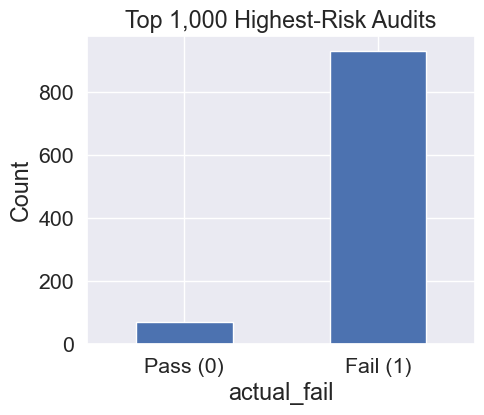

Top 1,000 high-risk audits – fail rate: 0.93


In [28]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------

top1000 = audit_df_sorted.head(1000)
top_counts = top1000["actual_fail"].value_counts().sort_index()  # 0 then 1

plt.figure(figsize=(5,4))
top_counts.plot(kind="bar")
plt.xticks([0,1], ["Pass (0)", "Fail (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Top 1,000 Highest-Risk Audits")
plt.show()

print("Top 1,000 high-risk audits – fail rate:",
      top1000["actual_fail"].mean())

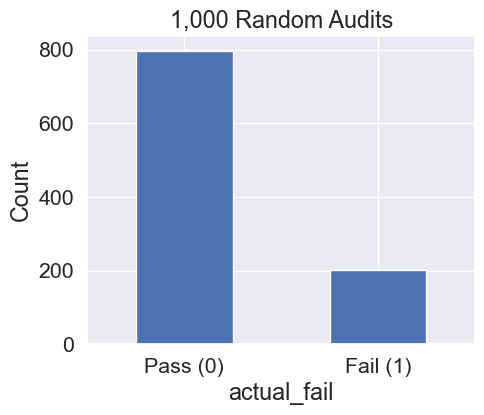

Random 1,000 audits – fail rate: 0.203


In [29]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------

random1000 = audit_df.sample(1000, random_state=42)
rand_counts = random1000["actual_fail"].value_counts().sort_index()

plt.figure(figsize=(5,4))
rand_counts.plot(kind="bar")
plt.xticks([0,1], ["Pass (0)", "Fail (1)"], rotation=0)
plt.ylabel("Count")
plt.title("1,000 Random Audits")
plt.show()

print("Random 1,000 audits – fail rate:",
      random1000["actual_fail"].mean())

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [30]:
# data processing
# -----------

# process features
X_test2014 = chicago_inspections_2014.drop(
    columns=['Results', 'Facility_Type', 'LICENSE_DESCRIPTION', 'WARD_PRECINCT'])

X_test2014 = pd.get_dummies(X_test2014, drop_first=True)

X_test2014 = X_test2014.reindex(columns=X.columns, fill_value=0)

X_test2014 = X_test2014.fillna(0) 

# process target 
y_test2014 = chicago_inspections_2014['Results']

y_test2014 = y_test2014.replace({'Pass w/ Conditions': 'Pass'})

lb_2014 = LabelBinarizer()
y_test2014 = lb_2014.fit_transform(y_test2014)

y_test2014 = np.where(y_test2014 == 1, 0, 1)   


In [31]:
# predict and compare 
# -----------
y_pred2014 = best_log.predict(X_test2014)


In [32]:
# evaluate
# -----------

print("Accuracy :", accuracy_score(y_test2014, y_pred2014))
print("Precision:", precision_score(y_test2014, y_pred2014))
print("Recall   :", recall_score(y_test2014, y_pred2014))
print("F1 score :", f1_score(y_test2014, y_pred2014))

Accuracy : 0.899199653904391
Precision: 0.6750202101859337
Recall   : 0.92880978865406
F1 score : 0.7818352059925093


## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


- The trade-off between false positives and false negatives will matter differently for different people (different errros have different consequences), and thus social scientists and public policy folks need to think beyond the numerical value of those metrics when deciding on the use and limiations on the models. 

- There can be other considerations that are not being captured by these models, and even more robust models might miss like questions around fairness and equity, and the weight of mistakes for different groups. 

- Accuracy can hide important mistakes. For example, a d model can look good, but it could still fail at at catching cases that social scientis/ public policy folks might care about.

- Imperfect real world data 


2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

- Introduce random inspections so that businesses cannot rely fully on predicting the algorithm.
  
- Include other types of business in the training data so the model reflects the real distribution of Chicago businesses.

- Retrain model over time

- Focus on long-term inspections since it's harder for restaurants to manipulate thier data/